# Análisis de Caso - Reducción dimensional‍

Para simular el problema de alta dimensionalidad descrito en el caso, se utilizó el dataset "Human Activity Recognition Using Smartphones" del repositorio UCI, consistente en una base de datos de reconocimiento de actividad humana creada a partir de grabaciones de 30 sujetos que realizaban actividades. El dataset contiene más de 500 variables derivadas de sensores de dispositivos móviles. Este tipo de dataset es ideal para aplicar técnicas de reducción dimensional como PCA y t-SNE, ya que permite observar cómo estas técnicas ayudan a simplificar estructuras complejas y facilitar la visualización de patrones en datos de alta dimensión.


In [18]:
# Importo librerías a utilizar
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


Leo el dataset

In [19]:
df = pd.read_csv("X_train.txt", sep="\s+", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


Cargo también etiquetas de actividad

In [20]:
y = pd.read_csv("y_train.txt", header=None)

Reviso estructura del Dataset

In [21]:
df.shape

(7352, 561)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, 0 to 560
dtypes: float64(561)
memory usage: 31.5 MB


In [23]:
df.isnull().sum().sum()

np.int64(0)

Aplico Estandarización

In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

**Aplico PCA**

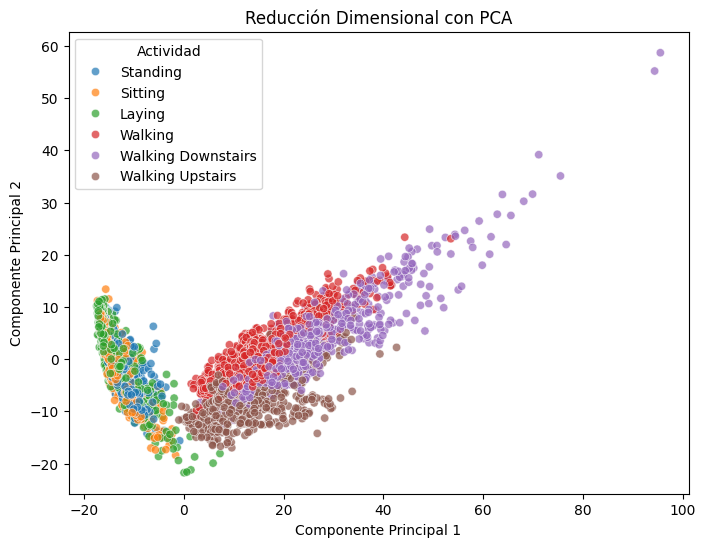

         PC1       PC2  Activity
0 -16.138544  2.152024  Standing
1 -15.296194  1.387144  Standing
2 -15.137019  2.473351  Standing
3 -15.350884  3.915681  Standing
4 -15.544814  4.598737  Standing

Varianza explicada por cada componente:
[0.50781172 0.0658068 ]

Varianza total explicada por las 2 componentes:
0.5736185255809916


In [25]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Crear dataframe para visualización
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# Agregar actividad al dataframe
pca_df["Activity"] = y

# Etiqueto de acuerdo al dataset
activity_labels = {
1:"Walking",
2:"Walking Upstairs",
3:"Walking Downstairs",
4:"Sitting",
5:"Standing",
6:"Laying"
}

pca_df["Activity"] = pca_df["Activity"].map(activity_labels)

# Gráfico PCA con colores
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Activity",
    palette="tab10",
    alpha=0.7
)

plt.title("Reducción Dimensional con PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.legend(title="Actividad")

plt.show()

print (pca_df.head())
# Mostrar varianza explicada
print("\nVarianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

print("\nVarianza total explicada por las 2 componentes:")
print(pca.explained_variance_ratio_.sum())

Las columnas PC1 y PC2 representan las dos componentes principales, que son nuevas variables creadas por PCA a partir de las 561 variables originales del dataset. Cada punto (fila) corresponde a una observación del dataset, en este caso una medición de actividad registrada por sensores del smartphone. La columna Activity indica la actividad real que estaba realizando la persona, por ejemplo Standing.

**Varianza explicada**      

- PC1 explica 50.78% de la varianza

- PC2 explica 6.58% de la varianza

En conjunto: Las dos componentes principales explican aproximadamente 57.36% de la información total del dataset.

Esto es, las dos componentes principales capturan aproximadamente el 57% de la varianza total del dataset, lo que indica que una gran parte de la información original puede representarse en dos dimensiones, facilitando la visualización y el análisis de patrones en los datos.

**Graficamente**: Cada color representa una actividad distinta registrada por los sensores del smartphone. La reducción dimensional permite observar cómo ciertas actividades presentan patrones similares mientras que otras se separan claramente en el espacio reducido.

**Aplico t-SNE**

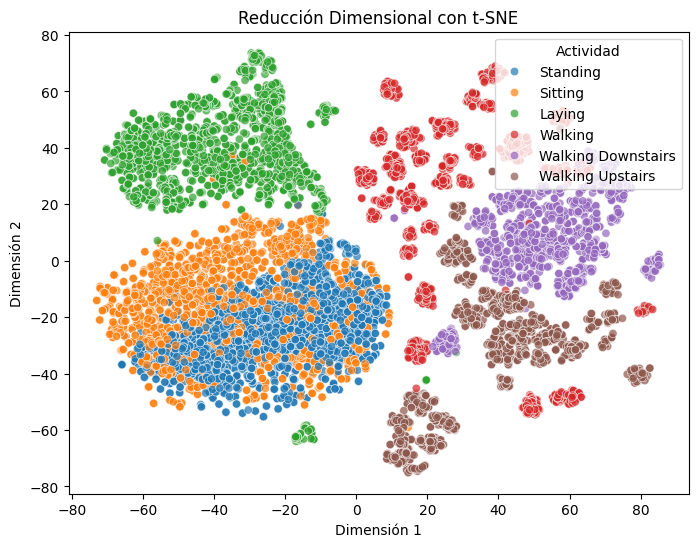

        Dim1       Dim2  Activity
0 -30.662092 -22.228291  Standing
1 -32.271252 -22.112267  Standing
2 -30.809223 -18.834967  Standing
3 -52.315308 -18.037588  Standing
4 -37.348713 -42.953434  Standing


In [26]:
# 1. Cargar dataset
X = pd.read_csv("X_train.txt", sep="\s+", header=None)

# 2. Cargar etiquetas
y = pd.read_csv("y_train.txt", header=None)

# 3. Escalar variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Aplicar t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

# 5. Crear dataframe para visualización
tsne_df = pd.DataFrame(X_tsne, columns=["Dim1", "Dim2"])

tsne_df["Activity"] = y

# 6. Reemplazar números por nombres de actividad
activity_labels = {
1:"Walking",
2:"Walking Upstairs",
3:"Walking Downstairs",
4:"Sitting",
5:"Standing",
6:"Laying"
}

tsne_df["Activity"] = tsne_df["Activity"].map(activity_labels)

# 7. Gráfico t-SNE
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=tsne_df,
    x="Dim1",
    y="Dim2",
    hue="Activity",
    palette="tab10",
    alpha=0.7
)

plt.title("Reducción Dimensional con t-SNE")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")

plt.legend(title="Actividad")

plt.show()

print (tsne_df.head())

La visualización obtenida mediante **la gráfica t-SNE** muestra agrupamientos más definidos entre las distintas actividades en comparación con PCA. Esto ocurre porque t-SNE es una técnica no lineal que preserva mejor las relaciones locales entre observaciones, facilitando la identificación de patrones y clusters en datos de alta dimensionalidad.

A diferencia de PCA, t-SNE no proporciona una medida de varianza explicada. En cambio, genera una representación bidimensional donde la proximidad entre puntos refleja similitudes en los datos originales. Esto permite visualizar agrupamientos o clusters que pueden corresponder a patrones subyacentes en el dataset.